# Steam Games Analysis

What drives a game's reach on Steam, and can it be predicted before launch?

This notebook works through a catalog of ~140,000 Steam games:

1. **Cleaning** the raw export, which turns out to carry several inconsistent schemas
2. **Feature engineering** from the catalog metadata
3. **EDA** on what correlates with reach and reception
4. **Modelling** a game's estimated-owners bucket from information available *before* launch

Source: `steam_games.csv` (~927MB raw).

In [58]:
import json
import os
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

RAW_CSV = "../steam_games.csv"
PROCESSED_PARQUET = "../data/processed/games.parquet"
sns.set_theme(style="whitegrid")

## 1. First look at the raw data

The raw file is ~927MB, so we start with a 5-row preview rather than loading all of it.

In [59]:
preview = pd.read_csv(RAW_CSV, nrows=5)
preview

,app_id,name,release_date,price,price_status,estimated_owners,developers,publishers,genres,categories,...,linux,header_image,screenshots,movies,website,support_url,support_email,metacritic_url,steam_store_available,steam_spy_available
0,876310,BIG POGO MAN,2018-06-25,4.99,paid,0 - 20000,"[""WooJuDev""]","[""WooJuDev""]","[""Adventure"", ""Casual"", ""Indie"", ""Sports""]","[""Single-player"", ""Steam Achievements"", ""Steam...",...,False,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,woojudev@gmail.com,NaN,True,True
1,876320,Hyperspace Delivery Service,2019-06-05,9.99,paid,0 - 20000,"[""Zotnip""]","[""Zotnip""]","[""Action"", ""Adventure"", ""Indie"", ""Simulation"",...","[""Single-player"", ""Steam Achievements"", ""Full ...",...,True,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],http://hyperspacedeliveryservice.com,http://hyperspacedeliveryservice.com,info@zotnip.com,NaN,True,True
2,876340,VR Slots 3D,2018-08-30,0.00,free,0 - 20000,"[""Belka VR""]","[""Belka VR""]","[""Casual"", ""Free To Play"", ""Indie"", ""Early Acc...","[""Single-player"", ""Tracked Controller Support""...",...,False,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,support@belkavr.com,NaN,True,True
3,876380,Underwater hunting,2018-06-20,0.99,paid,0 - 20000,"[""GiBar""]","[""RoBot""]","[""Adventure"", ""Indie"", ""RPG""]","[""Single-player"", ""Multi-player"", ""Co-op"", ""On...",...,False,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,robot72@yandex.ru,NaN,True,True
4,876410,Greenspawn Restaurant,2018-07-20,3.99,paid,0 - 20000,"[""Apple Dash""]","[""Apple Dash""]","[""Action"", ""Indie""]","[""Single-player"", ""Steam Achievements"", ""Famil...",...,True,https://shared.akamai.steamstatic.com/store_it...,"[""https://shared.akamai.steamstatic.com/store_...",[],NaN,NaN,fshpsmgc@gmail.com,NaN,True,True


In [60]:
preview.dtypes

app_id                        int64
name                            str
release_date                    str
price                       float64
price_status                    str
estimated_owners                str
developers                      str
publishers                      str
genres                          str
categories                      str
tags                            str
positive                      int64
negative                      int64
recommendations             float64
peak_ccu                      int64
metacritic_score            float64
user_score                    int64
average_playtime_forever      int64
median_playtime_forever       int64
average_playtime_2weeks       int64
median_playtime_2weeks        int64
short_description               str
about_the_game                  str
detailed_description            str
notes                       float64
achievements                float64
dlc_count                     int64
packages                    

`genres`, `categories`, `tags`, `developers` and `publishers` all come back as strings. Their values *look* like lists — `["Action", "Indie"]` — but pandas has no reason to parse them, so they stay text for now. Section 3 handles that.

## 2. Loading the full catalog

Most of the raw file's bulk is text and URLs we will never model on: full game descriptions, screenshot and video links, support emails. Passing `usecols` means pandas' parser skips those columns entirely rather than loading and then discarding them.

In [61]:
all_columns = pd.read_csv(RAW_CSV, nrows=0).columns.tolist()

drop_columns = [
    "about_the_game", "detailed_description", "notes", "header_image",
    "screenshots", "movies", "website", "support_url", "support_email",
    "metacritic_url",
]

usecols = [c for c in all_columns if c not in drop_columns]

# low_memory=False reads the file in a single pass. Besides avoiding pandas'
# chunked dtype guessing, it sidesteps a bug in pandas 3.0.5 that raises an
# IndexError while building the mixed-dtype warning for this file.
df = pd.read_csv(RAW_CSV, usecols=usecols, low_memory=False)

print(df.shape)
df.info(memory_usage="deep")

(139580, 32)
<class 'pandas.DataFrame'>
RangeIndex: 139580 entries, 0 to 139579
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   app_id                    139580 non-null  int64  
 1   name                      139564 non-null  str    
 2   release_date              139497 non-null  str    
 3   price                     138408 non-null  float64
 4   price_status              139580 non-null  str    
 5   estimated_owners          139580 non-null  str    
 6   developers                139580 non-null  str    
 7   publishers                139580 non-null  str    
 8   genres                    139580 non-null  str    
 9   categories                139580 non-null  str    
 10  tags                      139580 non-null  str    
 11  positive                  139580 non-null  int64  
 12  negative                  139580 non-null  int64  
 13  recommendations           107968 non-null 

## 3. Cleaning: four inconsistent schemas in one file

The list-like columns are not stored consistently across rows. Each of the issues below surfaced only as a downstream error, traced back to the offending value — none are visible in the first few rows:

| Issue | Example | Rows affected | Handling |
| --- | --- | --- | --- |
| A single value stored as a bare string instead of a JSON array | `supported_languages` = `English` rather than `["English"]` | few | wrap in a one-item list |
| Genres/categories stored as objects rather than names | `[{"id": "4", "description": "Casual"}, ...]` | few | keep the `description` value |
| Tags stored as a name → vote-count mapping instead of a list | `{"Indie": 131, "Action": 126, ...}` | ~23,500 | keep the keys |
| Platform flags mixing booleans with missing values | `windows` ∈ {`True`, `False`, `NaN`} | 15 | treat missing as `False` |

The tag vote counts are richer than what the other ~116,000 rows carry, but they cannot be used consistently across the dataset, so only the tag names are kept.

**Missing-value semantics.** A missing list is treated as "nothing listed" (`[]`) rather than "unknown", because for these columns the two amount to the same thing: a game with no `full_audio_languages` entry has no recorded full audio support. `description_length` is handled differently — see section 5.

In [62]:
parse_columns = [
    "genres", "categories", "tags", "developers", "publishers",
    "supported_languages", "full_audio_languages",
]


def parse_list(value):
    """Parse a JSON-encoded list cell, tolerating the schema variations above."""
    if isinstance(value, (list, dict)):
        return value  # already parsed; keeps the cell safe to re-run
    if pd.isna(value) or value == "":
        return []
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return [value]  # a bare string, e.g. supported_languages = "English"


def normalize_items(value):
    """Reduce a parsed cell to a flat list of names, whatever shape it arrived in."""
    if isinstance(value, dict):
        return list(value.keys())  # tags stored as name -> vote count
    return [
        item.get("description", str(item)) if isinstance(item, dict) else item
        for item in value
    ]


for col in parse_columns:
    df[col] = df[col].apply(parse_list).apply(normalize_items)

In [63]:
# Every parsed column should now hold plain lists of strings, and nothing else.
for col in parse_columns:
    top_level = set(df[col].apply(type))
    assert top_level == {list}, f"{col} holds non-list values: {top_level}"

    elements = {type(item) for lst in df[col] for item in lst}
    assert elements <= {str}, f"{col} holds non-string elements: {elements}"

print("all parsed columns hold lists of strings")

all parsed columns hold lists of strings


In [64]:
# Platform flags carry NaN alongside True/False, which forces the column to
# dtype object. Missing is read as "not supported".
for col in ["windows", "mac", "linux"]:
    df[col] = df[col].fillna(False).astype(bool)

df[["windows", "mac", "linux"]].dtypes

windows    bool
mac        bool
linux      bool
dtype: object

## 4. Feature engineering

Every feature here comes from information a developer would know *before* release — how the game is tagged, what it costs, which platforms it ships on. Post-launch signals (reviews, playtime, concurrent players) are deliberately left out of the model; including them would leak the outcome we are trying to predict.

In [65]:
for col in parse_columns:
    df[col + "_count"] = df[col].apply(len)

# The booleans are cast before summing: adding bool Series directly returns a
# boolean "any platform" result rather than a 0-3 count.
df["platform_count"] = (
    df["windows"].astype(int) + df["mac"].astype(int) + df["linux"].astype(int)
)

df["has_achievements"] = df["achievements"].fillna(0) > 0

df["platform_count"].value_counts().sort_index()

platform_count
0        17
1    110512
2     16559
3     12492
Name: count, dtype: int64

`positive_ratio` is EDA-only — it summarizes post-launch reception, so it is excluded from the model's features (see the leakage note in the modelling section). Dividing by zero reviews would otherwise silently become `NaN` via plain float division; the explicit `np.where` makes that "no signal yet" case visible in the code rather than relying on the reader to know the float-division quirk.

In [66]:
total_reviews = df["positive"] + df["negative"]
df["positive_ratio"] = np.where(total_reviews > 0, df["positive"] / total_reviews, np.nan)

df["positive_ratio"].isna().sum()
print(((df['positive'] == 0) & (df['negative'] == 0)).sum())

56519


In [67]:
df["price"].describe()

count    138408.000000
mean          9.025464
std         411.111628
min           0.000000
25%           0.990000
50%           4.990000
75%           9.990000
max      107500.000000
Name: price, dtype: float64

The median game is \$4.99 and the 75th percentile \$9.99, but the maximum is \$107,500 — an outlier that inflates the standard deviation to ~411. Rather than guess a ceiling that such values would silently fall outside of (landing them in an unbinned `NaN`), the top bucket is left open with `np.inf`.

In [68]:
# The first edge sits just below zero so that free games (price == 0.00) land
# in their own bucket; pd.cut's intervals exclude the left edge.
df["price_bucket"] = pd.cut(
    df["price"],
    bins=[-0.01, 0, 5, 20, np.inf],
    labels=["free", "budget", "mid", "premium"],
)

df["price_bucket"].value_counts()

price_bucket
budget     54953
mid        48861
free       27781
premium     6813
Name: count, dtype: int64

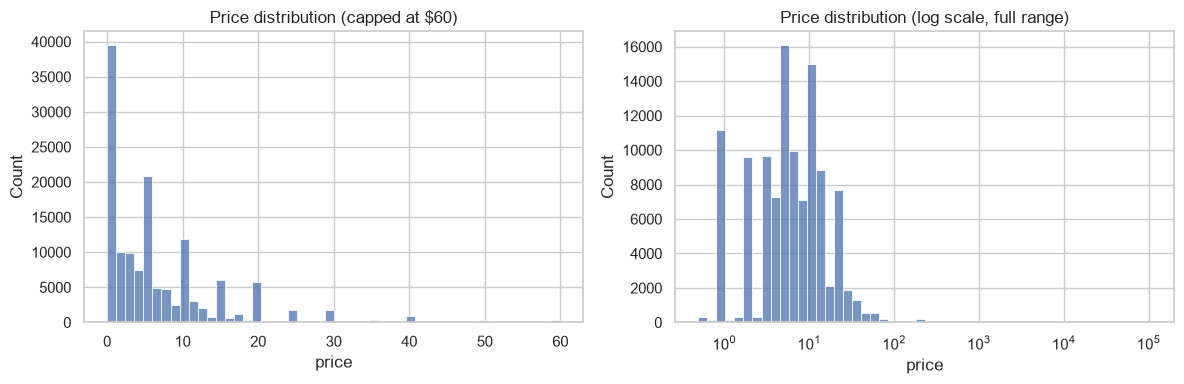

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df[df['price'] <= 60], x='price', bins=50, ax=axes[0])
axes[0].set_title('Price distribution (capped at $60)')

sns.histplot(data=df, x='price', bins=50, log_scale=True, ax=axes[1])
axes[1].set_title('Price distribution (log scale, full range)')

plt.tight_layout()

Prices cluster at conventional "charm price" points ($0.99, $4.99, $9.99, $14.99, $19.99, $29.99) rather than spreading smoothly across the range — developers anchor to these tiers by convention, producing a comb-like distribution instead of a bell curve. The tall spike at $0 is free-to-play games. On the log-scale view, the $107,500 outlier from `describe()` is essentially invisible: it is a single row, not a cluster, so it cannot form a visible bar even when the axis is compressed.

## 5. Dates and description length

`errors="coerce"` turns unparseable dates into `NaT` instead of raising — the same defensive stance the list parsing needed.

`description_length` keeps `NaN` where a game has no short description, rather than filling zero: a missing description is of unknown length, not zero length, and collapsing the two would tell the model that ~8,000 games have unusually terse store pages.

In [70]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month

df["description_length"] = df["short_description"].str.len()

df["release_year"].value_counts().sort_index()

release_year
1997.0        2
1998.0        1
1999.0        2
2000.0        2
2001.0        4
2002.0        1
2003.0        3
2004.0        6
2005.0        7
2006.0       69
2007.0       90
2008.0      158
2009.0      321
2010.0      255
2011.0      258
2012.0      322
2013.0      467
2014.0     1521
2015.0     2513
2016.0     4137
2017.0     5918
2018.0     7451
2019.0     7240
2020.0     8795
2021.0    11044
2022.0    12255
2023.0    14538
2024.0    19899
2025.0    24687
2026.0    17531
Name: count, dtype: int64

In [71]:
engineered = [
    "genres_count", "categories_count", "tags_count", "supported_languages_count",
    "platform_count", "has_achievements", "price_bucket", "description_length",
    "release_year", "release_month",
]

df[engineered].info()

<class 'pandas.DataFrame'>
RangeIndex: 139580 entries, 0 to 139579
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype   
---  ------                     --------------   -----   
 0   genres_count               139580 non-null  int64   
 1   categories_count           139580 non-null  int64   
 2   tags_count                 139580 non-null  int64   
 3   supported_languages_count  139580 non-null  int64   
 4   platform_count             139580 non-null  int64   
 5   has_achievements           139580 non-null  bool    
 6   price_bucket               138408 non-null  category
 7   description_length         131250 non-null  float64 
 8   release_year               139497 non-null  float64 
 9   release_month              139497 non-null  float64 
dtypes: bool(1), category(1), float64(3), int64(5)
memory usage: 8.8 MB


## 6. The target variable

`estimated_owners` arrives pre-bucketed as ranges, but the raw file encodes them inconsistently — a fifth schema issue, on top of the four in section 3. The same range appears in two different string formats depending on the row, e.g. `"20000 - 50000"` and `"20,000 .. 50,000"` are the same bucket. Left alone, this would fragment 14 real categories into 26, silently hurting any model trained on it.

In [72]:
def normalize_owners(label):
    """Collapse both raw formats (e.g. "20000 - 50000" and "20,000 .. 50,000")
    into one canonical string per range."""
    numbers = re.findall(r"[\d,]+", label)
    low, high = (int(n.replace(",", "")) for n in numbers)
    return f"{low} - {high}"


df["estimated_owners"] = df["estimated_owners"].apply(normalize_owners)

In [73]:
owners = df["estimated_owners"].value_counts()
print(owners)
print()
print((owners / len(df) * 100).round(2).astype(str) + "%")

estimated_owners
0 - 20000                92772
0 - 0                    21185
20000 - 50000            11410
50000 - 100000            5369
100000 - 200000           3469
200000 - 500000           2864
500000 - 1000000          1157
1000000 - 2000000          729
2000000 - 5000000          405
5000000 - 10000000         125
10000000 - 20000000         51
20000000 - 50000000         31
50000000 - 100000000         9
100000000 - 200000000        4
Name: count, dtype: int64

estimated_owners
0 - 20000                66.47%
0 - 0                    15.18%
20000 - 50000             8.17%
50000 - 100000            3.85%
100000 - 200000           2.49%
200000 - 500000           2.05%
500000 - 1000000          0.83%
1000000 - 2000000         0.52%
2000000 - 5000000         0.29%
5000000 - 10000000        0.09%
10000000 - 20000000       0.04%
20000000 - 50000000       0.02%
50000000 - 100000000      0.01%
100000000 - 200000000      0.0%
Name: count, dtype: str


Normalizing collapses 26 raw labels into 14 real buckets — but it also exposes a severe class imbalance: 66.47% of games fall in the lowest bucket (`0 - 20000`), another 15.18% have zero recorded owners, and the top bucket (`100000000 - 200000000`) holds only 4 games out of 139,580. A classifier trained naively here could reach high raw accuracy just by always predicting the majority bucket, so the modelling section evaluates with class-aware metrics (e.g. per-class F1) rather than accuracy alone.

## 7. What genres, tags, and platforms dominate the catalog

`genres` and `tags` are list columns — one game can carry several — so counting how often each value appears requires `explode()`, which turns a row's list into one row per item before counting. Platform support is already boolean, so it just needs summing.

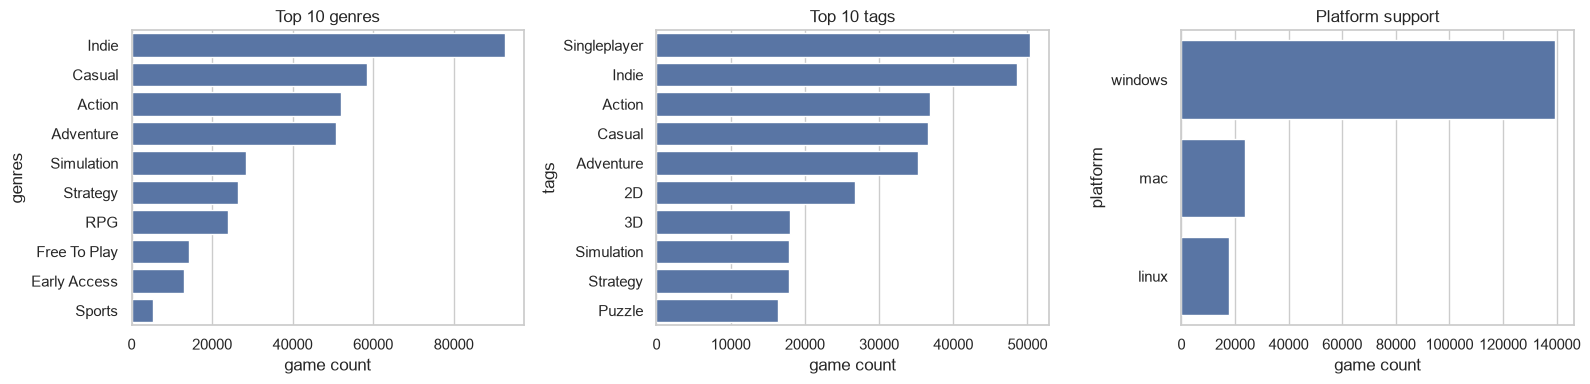

In [74]:
top_genres = df.explode("genres")["genres"].value_counts().head(10)
top_tags = df.explode("tags")["tags"].value_counts().head(10)
platform_support = df[["windows", "mac", "linux"]].sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0])
axes[0].set_title("Top 10 genres")
axes[0].set_xlabel("game count")

sns.barplot(x=top_tags.values, y=top_tags.index, ax=axes[1])
axes[1].set_title("Top 10 tags")
axes[1].set_xlabel("game count")

sns.barplot(x=platform_support.values, y=platform_support.index, ax=axes[2])
axes[2].set_title("Platform support")
axes[2].set_xlabel("game count")
axes[2].set_ylabel("platform")

plt.tight_layout()

Indie accounts for 66.5% of all games in the catalog — the single largest genre by a wide margin over the next closest, Casual. This lines up with Steam being flooded with small and solo-developer releases.

"Singleplayer" is the single most common tag, ahead of every genre. This is a supply-side signal, not evidence of player preference: the dataset counts what got built and published, not what players chose to play. Singleplayer games are cheaper and simpler for small Indie teams to build than multiplayer ones — no netcode, matchmaking, or server infrastructure — so the tag's dominance likely reflects what is easy to produce at this scale, not player demand.

The same story shows up in platform support: Windows is essentially universal (~139K games) while Mac (~23K) and Linux (~18K) are a small minority. From section 4's `platform_count` breakdown, 110,512 games support only one platform against just 12,492 that support all three — porting and maintaining builds for multiple platforms is extra engineering effort, so most small teams target only the platform with the largest install base and stop there.

## 8. Price vs. owners bucket

`estimated_owners` is a string column, so pandas has no idea `"20000 - 50000"` comes before `"100000 - 200000"` — a plain alphabetical sort would misorder them. `owner_order` sorts the bucket labels by their actual numeric bounds so every chart in this section displays the buckets correctly, smallest to largest.

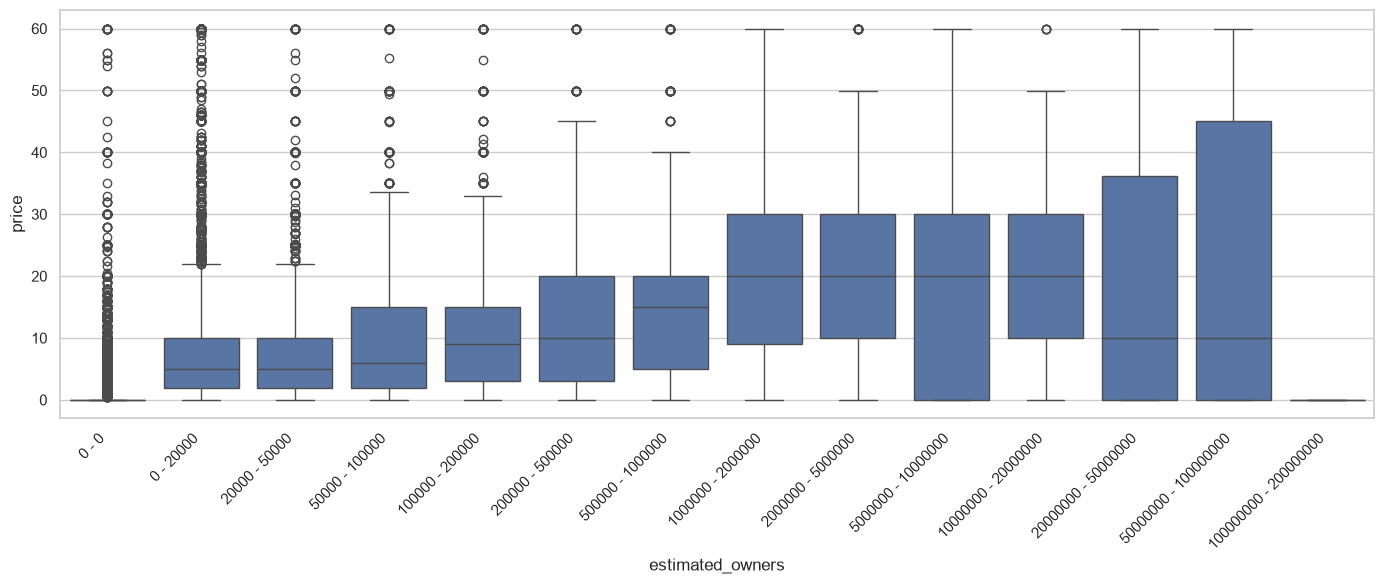

In [75]:
def bucket_bounds(label):
    low, high = label.split(' - ')
    return int(low), int(high)

owner_order = sorted(df['estimated_owners'].unique(), key=bucket_bounds)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['price'] <= 60], x='estimated_owners', y='price', order=owner_order)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

The chart shows that higher owners buckets tend to have a higher median price, which runs counter to the assumption that cheaper games sell more. The flattest boxes at the top of the chart shouldn't be read too literally, though — the `100000000 - 200000000` bucket has only 4 games, `50000000 - 100000000` has 9, and `20000000 - 50000000` has 31. With that few data points, a single unusual value can flatten the whole box, so the apparent "biggest hits are free" pattern likely reflects insufficient data rather than a real trend.

## 9. Platform, genre, and tag counts vs. owners bucket

tags_count
21        2
20    33494
19     2678
18     2812
17     2890
16     2819
15     2663
14     2597
13     2491
12     2445
Name: count, dtype: int64

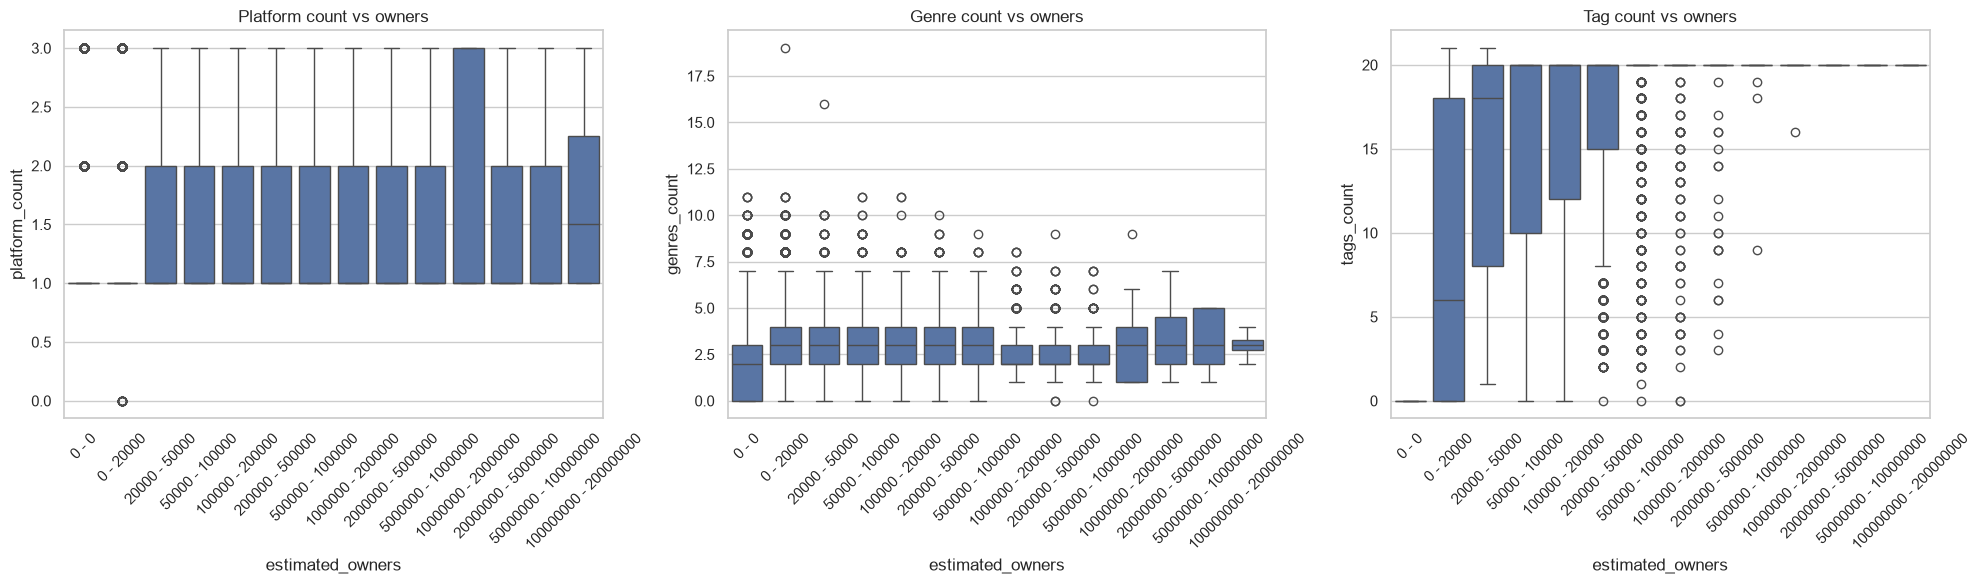

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='estimated_owners', y='platform_count', order=owner_order, ax=axes[0])
axes[0].set_title('Platform count vs owners')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='estimated_owners', y='genres_count', order=owner_order, ax=axes[1])
axes[1].set_title('Genre count vs owners')
axes[1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='estimated_owners', y='tags_count', order=owner_order, ax=axes[2])
axes[2].set_title('Tag count vs owners')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()

df['tags_count'].value_counts().sort_index(ascending=False).head(10)

Platform count shows a mild upward trend with owners (median climbs from 1 in the smallest buckets to 2 in most mid/large ones) — bigger, more successful titles can justify the extra engineering cost of porting to Mac and Linux. Genre count stays essentially flat across buckets and doesn't discriminate much on its own.

Tag count is the interesting one: from roughly the `200000 - 500000` bucket upward, the box collapses to a tight sliver sitting almost exactly at 20. That's worth investigating directly rather than trusting the chart at face value.

In [77]:
df['tags_count'].value_counts().sort_index(ascending=False).head(10)

tags_count
21        2
20    33494
19     2678
18     2812
17     2890
16     2819
15     2663
14     2597
13     2491
12     2445
Name: count, dtype: int64

**A sixth data limitation: `tags_count` is capped, not organic.** 33,494 games sit at *exactly* 20 tags, while every neighboring count is far smaller and roughly smooth (19 → 2,678, 18 → 2,812, 17 → 2,890, ... 21 → only 2). A real, uncapped tagging process wouldn't produce a 12x spike at one specific number followed by an almost total drop-off — that pattern is the signature of a hard cutoff. Whatever scraper produced this Kaggle dataset appears to have only recorded up to 20 tags per game, silently truncating anything beyond that.

This is a different kind of issue than the four schema inconsistencies in section 3: nothing here is malformed, every value is a valid integer, but the column can no longer distinguish games above the cap from each other. A game with 22 real community tags and one with 2,000 both read as `20`. That is exactly why the box plot flattens for popular games: it is not that hit games "settle" around 20 tags, it is that the dataset cannot see past 20 for them. `tags_count` should be treated as a reliable signal only below the cap; above it, its value is an artifact of collection, not of the game's real popularity.

In [78]:
comparison = pd.crosstab(df['estimated_owners'], df['price_status'], normalize='index') * 100
comparison = comparison.reindex(owner_order)
comparison

price_status,free,paid,unavailable
estimated_owners,,,
0 - 0,76.209582,23.790418,0.000000
0 - 20000,8.650239,86.905532,4.444229
20000 - 50000,13.567046,86.073620,0.359334
50000 - 100000,15.421866,84.242876,0.335258
100000 - 200000,16.344768,83.136351,0.518882
200000 - 500000,16.620112,83.100559,0.279330
500000 - 1000000,17.545376,81.676750,0.777874
1000000 - 2000000,17.558299,81.618656,0.823045
2000000 - 5000000,17.530864,82.222222,0.246914


Free games' share climbs steadily through the middle buckets (roughly 13-17%) and then jumps sharply at the top: 28% at 5-10M owners, 35.5% at 20-50M, 44.4% at 50-100M, and 100% at the very top bucket (100-200M). Games that reach massive scale skew free-to-play far more than the rest of the catalog — removing the purchase barrier is one of the most effective ways to maximize install count.

This also refines a caveat from section 8: the price-vs-owners box plot showed a flat box at $0 for the top bucket, which was attributed there mainly to having only 4 games. This table shows it is not just a small-sample artifact — all 4 of those games are genuinely free. The small sample size still limits how far this should be generalized, but the flat box was accurate, not noise.

In [79]:
df['price_status'].value_counts()

price_status
paid           107293
free            28057
unavailable      4230
Name: count, dtype: int64

A third `price_status` value shows up here that hasn't come up yet: `unavailable`, at 4,230 games (~3%). Worth a quick investigation rather than assuming what it means.

In [80]:
df[df['price_status'] == 'unavailable']['price'].isna().sum()

np.int64(428)

In [81]:
pd.crosstab(df['price_status'], df['steam_store_available'])

steam_store_available,False,True
price_status,,
free,0,28057
paid,0,107293
unavailable,15,4215


**A seventh data limitation: `price_status = "unavailable"` doesn't mean what it sounds like.** Two hypotheses, tested and ruled out:

- *"No price was ever recorded"* — false. Only 428 of the 4,230 `unavailable` rows actually have a missing `price`; the rest carry a real value.
- *"Delisted from the store"* — false. 4,215 of the 4,230 still show `steam_store_available = True`.

The most likely remaining explanation is a scraping artifact: whatever process built this Kaggle dataset probably fetched live pricing separately from the rest of a game's metadata, and for these ~3% of games that specific fetch failed or was rate-limited, independent of whether the game's store page itself was reachable. `unavailable` most likely means "pricing could not be confirmed at scrape time," not a real fact about the game. Left as-is in the data (relabeling it "free" or "paid" would be guessing), but worth knowing before drawing conclusions from `price_status` elsewhere.

## 12. Release year trends

Comparing raw `estimated_owners` across release years would be misleading: it is a cumulative count taken at whatever point the dataset was scraped, so an older game has simply had far more time to accumulate owners than a recent one. A 2025 game showing fewer owners than a 2015 game does not necessarily mean it is less successful — it may just not have had time yet. This is a maturity (time-since-release) bias, not evidence about game quality.

To sidestep this, we look at the *share* of each release year's games that land in the lowest owners bucket (`0 - 20000`) rather than raw owner counts — if maturity bias is the main driver, that share should climb for more recent years, since younger games haven't had time to grow out of the lowest bucket yet.

Text(0.5, 0, 'release year')

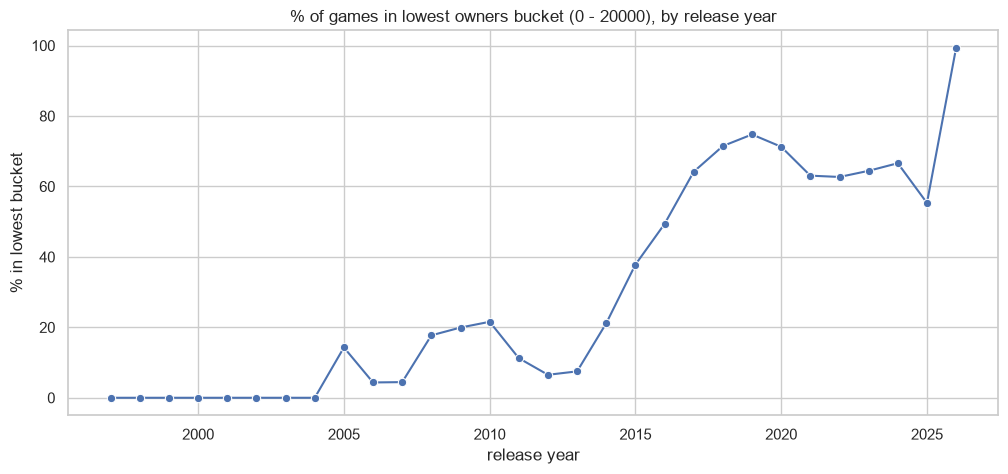

In [82]:
share_lowest = pd.crosstab(df['release_year'], df['estimated_owners'], normalize='index')['0 - 20000'] * 100
share_lowest

plt.figure(figsize=(12, 5))
sns.lineplot(x=share_lowest.index, y=share_lowest.values, marker='o')
plt.title('% of games in lowest owners bucket (0 - 20000), by release year')
plt.ylabel('% in lowest bucket')
plt.xlabel('release year')

The trend broadly confirms maturity bias: the lowest-bucket share climbs from single digits in the early years to 60-70% by the late 2010s, and hits 99.4% for 2026 — this year's releases have barely had any time to accumulate owners at all.

One point breaks the clean story, though: **2025 (55.3%) sits lower than 2024 (66.6%)**, which is backwards if maturity bias were the only thing at play (a younger release year should have a *higher* share in the lowest bucket, not lower) — and 2025 is not a small sample; at 24,687 games it is the single largest release year in the dataset. One available signal was checked as a possible explanation:

In [83]:
pd.crosstab(df['release_year'], df['steam_spy_available'], normalize='index') * 100

steam_spy_available,True
release_year,
1997.0,100.0
1998.0,100.0
1999.0,100.0
2000.0,100.0
2001.0,100.0
2002.0,100.0
2003.0,100.0
2004.0,100.0
2005.0,100.0


`steam_spy_available` is `True` for every single release year without exception, so it cannot distinguish anything — this test came back uninformative rather than conclusive, ruling nothing in or out. At this point the 2025 dip is left as an **open question**: a real, non-trivial pattern in a well-populated year, with no confirmed explanation available from the columns in this dataset. Two hypotheses remain plausible but unverified — a change in how or when the data was scraped for the newest releases, or some lag in how `estimated_owners` itself gets calculated for very recent games — but neither can be confirmed here. Reported honestly as unresolved rather than forced into a tidy story.

**Implication for modelling.** Because of maturity bias, `release_year` should be expected to correlate strongly with `estimated_owners` for reasons that have nothing to do with a game's actual quality or appeal — it is largely a proxy for "how long has this game had to accumulate owners," not a causal driver of success. It stays in the model as a pre-launch-available feature per the design spec, but this correlation should not be over-interpreted as "newer games are worse."

## 13. Preparing the modelling dataset

Two deliberate decisions before any model is trained.

**Zero-owner games are dropped.** The `0 - 0` bucket holds 21,185 games (15.18%) with literally zero recorded owners. These are almost certainly unreleased, delisted, or otherwise broken catalog entries rather than games that launched and genuinely sold nothing — section 10 already showed 76% of them are "free", which fits placeholder and pre-release listings far better than it fits commercial flops. Training on them would teach the model to recognise data artifacts rather than commercial outcomes. Dropping them sharpens the question the model answers to: *among games that actually launched, how large an audience will this reach?*

**The five smallest buckets are merged into one `5000000+` class.** They hold 125, 51, 31, 9 and 4 games respectively. A 4-game class cannot be split meaningfully into train and test — it yields roughly one test sample, and a per-class F1 computed from one sample is noise dressed up as a metric. Merging them leaves 9 classes that can each be evaluated honestly, the smallest holding 220 games.

In [84]:
TOP_BUCKETS = [
    "5000000 - 10000000", "10000000 - 20000000", "20000000 - 50000000",
    "50000000 - 100000000", "100000000 - 200000000",
]

# .copy() gives an independent frame: assigning to a slice would raise
# SettingWithCopyWarning, and df itself stays intact for the dashboard.
model_df = df[df["estimated_owners"] != "0 - 0"].copy()
model_df["owners_class"] = model_df["estimated_owners"].replace(
    {bucket: "5000000+" for bucket in TOP_BUCKETS}
)

class_order = [b for b in owner_order if b not in TOP_BUCKETS and b != "0 - 0"] + ["5000000+"]

print(f"{len(model_df):,} games, {model_df['owners_class'].nunique()} classes")
model_df["owners_class"].value_counts().reindex(class_order)

118,395 games, 9 classes


owners_class
0 - 20000            92772
20000 - 50000        11410
50000 - 100000        5369
100000 - 200000       3469
200000 - 500000       2864
500000 - 1000000      1157
1000000 - 2000000      729
2000000 - 5000000      405
5000000+               220
Name: count, dtype: int64

## 14. Features: what the model is allowed to see

The features below are all knowable *before* a game launches — how it is priced, how it is tagged, which platforms it ships on, how long its store description is.

**Deliberately excluded as leakage:** `positive`, `negative`, `recommendations`, `peak_ccu`, `user_score`, `metacritic_score`, `positive_ratio` and every `*_playtime_*` column. These are all post-launch outcomes that correlate strongly with owner counts — a model given them would score impressively and mean nothing, because none of them exist at the moment a developer is making the decisions this model is meant to inform.

**`price_bucket` is also excluded**, for a different reason: it is `price` cut into four ranges, so for a tree-based model it carries no information `price` does not already carry. Trees find their own split points, and they can find better ones than hand-chosen $0/$5/$20 edges. (It would matter for a linear model, which cannot discover thresholds on its own.)

**Missing values are left as `NaN` on purpose.** `HistGradientBoostingClassifier` handles them natively — it learns which side of each split missing values belong on. That is why `description_length` was kept as `NaN` back in section 5 rather than filled with zero: the model can treat "no description" as its own signal instead of being told, falsely, that those games have zero-character descriptions.

In [85]:
BASE_FEATURES = [
    "price",
    "platform_count",
    "dlc_count",
    "has_achievements",
    "description_length",
    "genres_count",
    "categories_count",
    "tags_count",
    "supported_languages_count",
    "full_audio_languages_count",
    "release_month",
]

X = model_df[BASE_FEATURES].astype(float)  # bool -> float so every column is numeric
y = model_df["owners_class"]

print(X.shape, y.shape)
X.head()

(118395, 11) (118395,)


,price,platform_count,dlc_count,has_achievements,description_length,genres_count,categories_count,tags_count,supported_languages_count,full_audio_languages_count,release_month
0,4.99,2.0,0.0,1.0,125.0,4.0,4.0,4.0,1.0,0.0,6.0
1,9.99,3.0,1.0,1.0,268.0,5.0,6.0,20.0,1.0,0.0,6.0
2,0.00,1.0,0.0,0.0,140.0,4.0,3.0,5.0,1.0,1.0,8.0
3,0.99,1.0,2.0,1.0,230.0,3.0,6.0,6.0,2.0,0.0,6.0
4,3.99,2.0,0.0,1.0,209.0,2.0,3.0,2.0,1.0,0.0,7.0


## 15. Train/test split

`stratify=y` makes the split preserve each class's proportion in both halves. Without it, a random 80/20 split of a set this imbalanced could easily hand the test set a wildly unrepresentative slice of the 220-game `5000000+` class — or, for a rarer class still, none at all, which would make that class impossible to evaluate. `random_state=42` fixes the shuffle so the split is reproducible across runs.

In [86]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"train: {len(X_train):,}   test: {len(X_test):,}")
print()
print(y_test.value_counts().reindex(class_order))

train: 94,716   test: 23,679

owners_class
0 - 20000            18554
20000 - 50000         2282
50000 - 100000        1074
100000 - 200000        694
200000 - 500000        573
500000 - 1000000       231
1000000 - 2000000      146
2000000 - 5000000       81
5000000+                44
Name: count, dtype: int64


## 16. Baseline model, and why accuracy lies

First model: `HistGradientBoostingClassifier` with default settings and no class weighting. The point of running it this way is to see the imbalance problem happen rather than just assert it.

In [88]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

baseline = HistGradientBoostingClassifier(random_state=42)
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, baseline_pred):.3f}")
print()
print(classification_report(y_test, baseline_pred, labels=class_order, zero_division=0))

accuracy: 0.783

                   precision    recall  f1-score   support

        0 - 20000       0.79      1.00      0.88     18554
    20000 - 50000       0.00      0.00      0.00      2282
   50000 - 100000       0.00      0.00      0.00      1074
  100000 - 200000       0.21      0.00      0.01       694
  200000 - 500000       0.09      0.01      0.01       573
 500000 - 1000000       0.20      0.03      0.06       231
1000000 - 2000000       0.23      0.12      0.16       146
2000000 - 5000000       0.07      0.09      0.08        81
         5000000+       0.05      0.07      0.06        44

         accuracy                           0.78     23679
        macro avg       0.18      0.15      0.14     23679
     weighted avg       0.63      0.78      0.69     23679



In [89]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

print(f"always-guess-majority accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.3f}")
print(f"trained model accuracy:         {accuracy_score(y_test, baseline_pred):.3f}")

always-guess-majority accuracy: 0.784
trained model accuracy:         0.783


**78% accuracy, and completely worthless.** The trained model scores 0.783; a `DummyClassifier` that ignores every feature and blindly answers `0 - 20000` every single time scores 0.784. The model with eleven features and a gradient-boosted ensemble behind it is fractionally *worse* than guessing.

The classification report shows exactly how: recall on `0 - 20000` is 1.00 (it predicts the majority class for essentially everything), while recall on `20000 - 50000` and `50000 - 100000` is 0.00 — 3,356 test games between them, not one identified. Macro F1, which averages across classes without letting the biggest one dominate, sits at 0.14 against that headline accuracy of 0.78.

This is the concrete version of the warning in section 6. If this project reported "78% accuracy predicting game success" and stopped there, the number would be technically true and completely misleading. The metrics that matter here are per-class recall and macro F1, and by those measures the baseline has failed.

## 17. Class weighting

`class_weight="balanced"` tells the model to weight each class inversely to how often it appears, so a mistake on one of the 176 training examples of `5000000+` costs roughly as much as a mistake on the 74,000-odd examples of `0 - 20000`. Without it the loss function is dominated by the majority class and the cheapest strategy is simply to always predict it — which is precisely what happened above.

Expect accuracy to *drop*. That is the point, not a regression: the model stops buying a high headline number with a strategy that never identifies anything interesting, and starts making real attempts at the smaller classes. Macro F1 is the metric to watch.

In [90]:
from sklearn.metrics import f1_score

balanced = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
balanced.fit(X_train, y_train)

balanced_pred = balanced.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, balanced_pred):.3f}"
      f"   (baseline was {accuracy_score(y_test, baseline_pred):.3f})")
print(f"macro F1: {f1_score(y_test, balanced_pred, average='macro'):.3f}"
      f"   (baseline was {f1_score(y_test, baseline_pred, average='macro'):.3f})")
print()
print(classification_report(y_test, balanced_pred, labels=class_order, zero_division=0))

accuracy: 0.523   (baseline was 0.783)
macro F1: 0.193   (baseline was 0.140)

                   precision    recall  f1-score   support

        0 - 20000       0.96      0.59      0.73     18554
    20000 - 50000       0.16      0.44      0.24      2282
   50000 - 100000       0.09      0.21      0.13      1074
  100000 - 200000       0.07      0.14      0.10       694
  200000 - 500000       0.11      0.15      0.12       573
 500000 - 1000000       0.07      0.17      0.10       231
1000000 - 2000000       0.08      0.28      0.12       146
2000000 - 5000000       0.06      0.28      0.09        81
         5000000+       0.07      0.27      0.11        44

         accuracy                           0.52     23679
        macro avg       0.19      0.28      0.19     23679
     weighted avg       0.78      0.52      0.61     23679



Weighting did what it was supposed to: every class now gets non-zero recall, macro recall climbs from 0.15 to 0.28, and macro F1 from 0.140 to 0.193. Accuracy falls from 0.783 to 0.523, which is the expected price of no longer buying a headline number with a do-nothing strategy.

It is still a weak model, and worth saying so plainly: minority-class precision sits between 0.06 and 0.16, so when it predicts a game will reach millions of owners it is usually wrong. But F1 treats every mistake as equally bad, and these classes are *ordinal* — guessing `20000 - 50000` when the answer is `50000 - 100000` is a near miss, while guessing `5000000+` for a game that sold nothing is a disaster. A confusion matrix distinguishes the two; F1 cannot.

exactly right:        52.3%
within one bucket:    78.7%
off by 3 or more:     11.1%


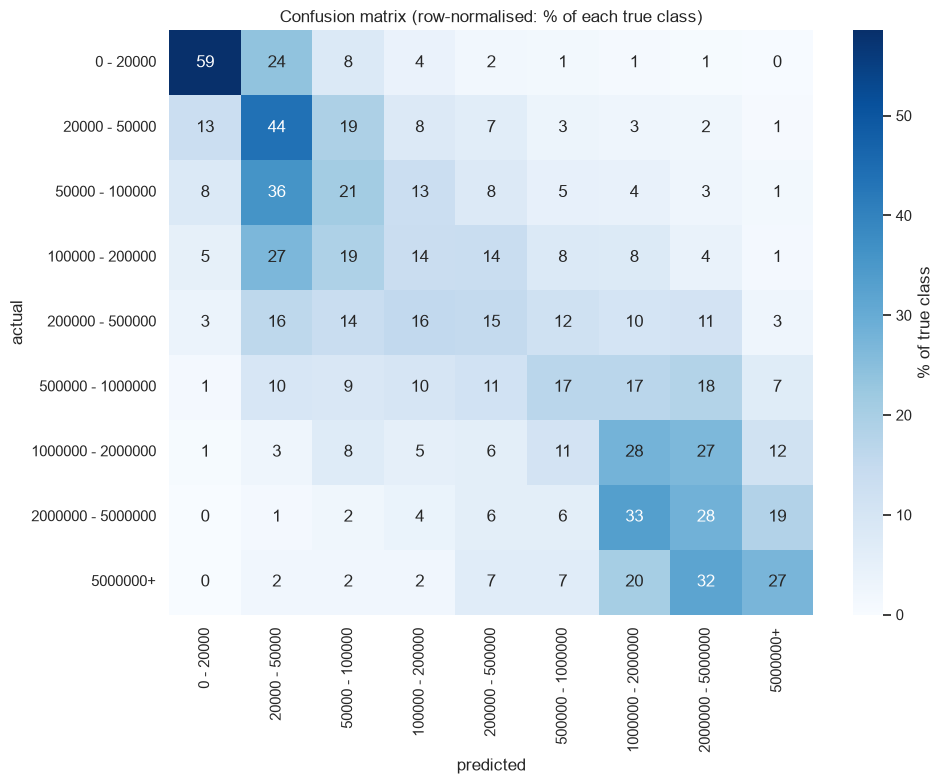

In [91]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, balanced_pred, labels=class_order, normalize="true") * 100

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of true class"},
    xticklabels=class_order, yticklabels=class_order,
)
plt.title("Confusion matrix (row-normalised: % of each true class)")
plt.ylabel("actual")
plt.xlabel("predicted")
plt.tight_layout()

# How often is the prediction the correct bucket, or one bucket either side?
rank = {label: i for i, label in enumerate(class_order)}
off_by = (y_test.map(rank).to_numpy() - pd.Series(balanced_pred).map(rank).to_numpy())
print(f"exactly right:        {(off_by == 0).mean() * 100:.1f}%")
print(f"within one bucket:    {(abs(off_by) <= 1).mean() * 100:.1f}%")
print(f"off by 3 or more:     {(abs(off_by) >= 3).mean() * 100:.1f}%")

The confusion matrix tells a much better story than macro F1 did, and the reason is that F1 cannot see ordering.

Mass concentrates in a diagonal band, and the two far corners are empty: of games that actually reached `5000000+` owners, **0%** were predicted as `0 - 20000`, and of games in `0 - 20000`, **0%** were predicted as `5000000+`. The model does not confuse mega-hits with flops. Overall, 52.3% of predictions land in exactly the right bucket, 78.7% land within one bucket either side, and only 11.1% are off by three or more.

That headline "within one bucket" figure is partly carried by the majority class, so the minority rows matter more as evidence — and they show the same pattern:

| Actual class | Exact | Within one bucket |
| --- | --- | --- |
| `1000000 - 2000000` | 28% | 66% |
| `2000000 - 5000000` | 28% | 80% |
| `5000000+` | 27% | 59% |

So the honest summary is neither "78% accurate" nor "macro F1 0.19, failed". The model cannot reliably name the exact owners bucket — but it *can* rank games by expected reach, and it rarely misplaces one by more than an order of magnitude. For a model that sees only pre-launch catalog metadata — no marketing spend, no review scores, no streamer coverage, no gameplay quality — that is a reasonable amount of signal, and it suggests those unmeasured factors are where most of the real variance lives.

## 18. Better features: what the game *is*, not just how much of it there is

So far the model has only seen *counts* — how many tags, how many genres, how many platforms. It has never been told that a game is tagged `Soulslike` or `Idle`, or that its publisher has shipped four hundred other titles. Those are all knowable before launch and are plausibly far more informative than the counts.

Three additions:

- **Multi-hot genre, tag and category columns.** A list column cannot be fed to the model directly, so each of the most common values becomes its own 0/1 column (`genre_Indie`, `tag_Soulslike`, and so on). Only the most frequent are kept — a tag appearing on nine games out of 118,000 cannot support a split and only adds noise and width.
- **`publisher_game_count`** — how many games this game's publisher has in the catalog, which separates established publishers from one-game solo developers.

**And one deliberately not built.** "Average owners of this publisher's other games" sounds like fair pre-launch knowledge — a publisher's track record does exist before a new release. But computed from this dataset it is built *from the target column*, and each game contributes to its own publisher's average, so the model would be handed a blurred copy of the answer it is meant to predict. It would score beautifully here and fail on anything genuinely new. Doing it honestly needs out-of-fold computation, so it is left out. `publisher_game_count` gets at the same idea — publisher scale — without ever touching `estimated_owners`.

In [92]:
def multi_hot(series, prefix, top_n):
    """Turn a column of lists into one 0/1 column per value, for the top_n most common values."""
    keep = series.explode().value_counts().head(top_n).index
    return pd.DataFrame(
        {f"{prefix}_{value}": series.apply(lambda items: int(value in items)) for value in keep},
        index=series.index,
    )


genre_cols = multi_hot(model_df["genres"], "genre", 20)
tag_cols = multi_hot(model_df["tags"], "tag", 60)
category_cols = multi_hot(model_df["categories"], "cat", 25)

# Publisher scale: how many catalog games share this game's publisher.
publisher_counts = df.explode("publishers")["publishers"].value_counts()
model_df["publisher_game_count"] = model_df["publishers"].apply(
    lambda names: max((publisher_counts.get(n, 0) for n in names), default=0)
)

X_rich = pd.concat(
    [model_df[BASE_FEATURES + ["publisher_game_count"]].astype(float),
     genre_cols, tag_cols, category_cols],
    axis=1,
)

print(f"{X.shape[1]} features -> {X_rich.shape[1]} features")
X_rich.head()

11 features -> 117 features


,price,platform_count,dlc_count,has_achievements,description_length,genres_count,categories_count,tags_count,supported_languages_count,full_audio_languages_count,...,cat_Shared/Split Screen,cat_Online Co-op,cat_Save Anytime,cat_Stereo Sound,cat_Mouse Only Option,cat_Stats,cat_Tracked Controller Support,cat_VR Only,cat_Shared/Split Screen PvP,cat_Shared/Split Screen Co-op
0,4.99,2.0,0.0,1.0,125.0,4.0,4.0,4.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,9.99,3.0,1.0,1.0,268.0,5.0,6.0,20.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.00,1.0,0.0,0.0,140.0,4.0,3.0,5.0,1.0,1.0,...,0,0,0,0,0,0,1,0,0,0
3,0.99,1.0,2.0,1.0,230.0,3.0,6.0,6.0,2.0,0.0,...,0,1,0,0,0,0,0,0,0,0
4,3.99,2.0,0.0,1.0,209.0,2.0,3.0,2.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [93]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_rich, y, test_size=0.2, stratify=y, random_state=42
)

rich = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
rich.fit(Xr_train, yr_train)
rich_pred = rich.predict(Xr_test)

rich_off_by = (yr_test.map(rank).to_numpy() - pd.Series(rich_pred).map(rank).to_numpy())

print(f"{'':<22}{'11 features':>14}{'117 features':>15}")
print(f"{'accuracy':<22}{accuracy_score(y_test, balanced_pred):>14.3f}{accuracy_score(yr_test, rich_pred):>15.3f}")
print(f"{'macro F1':<22}{f1_score(y_test, balanced_pred, average='macro'):>14.3f}"
      f"{f1_score(yr_test, rich_pred, average='macro'):>15.3f}")
print(f"{'exactly right':<22}{(off_by == 0).mean():>14.3f}{(rich_off_by == 0).mean():>15.3f}")
print(f"{'within one bucket':<22}{(abs(off_by) <= 1).mean():>14.3f}{(abs(rich_off_by) <= 1).mean():>15.3f}")
print()
print(classification_report(yr_test, rich_pred, labels=class_order, zero_division=0))

                         11 features   117 features
accuracy                       0.523          0.613
macro F1                       0.193          0.248
exactly right                  0.523          0.613
within one bucket              0.787          0.855

                   precision    recall  f1-score   support

        0 - 20000       0.96      0.69      0.80     18554
    20000 - 50000       0.19      0.45      0.27      2282
   50000 - 100000       0.14      0.23      0.17      1074
  100000 - 200000       0.13      0.20      0.16       694
  200000 - 500000       0.16      0.24      0.19       573
 500000 - 1000000       0.09      0.20      0.12       231
1000000 - 2000000       0.14      0.32      0.19       146
2000000 - 5000000       0.10      0.22      0.14        81
         5000000+       0.16      0.25      0.19        44

         accuracy                           0.61     23679
        macro avg       0.23      0.31      0.25     23679
     weighted avg       0.79 

Knowing *what* a game is beats knowing *how many* attributes it has. Every metric improves: macro F1 from 0.193 to 0.248, exact-bucket hits from 52.3% to 61.3%, and within-one-bucket from 78.7% to 85.5%. Precision on the `5000000+` class more than doubles, from 0.07 to 0.16.

It is still not a model anyone should bet a studio's budget on — minority-class precision stays low, and most predictions of a breakout hit are still wrong. But the gain from adding genre, tag, category and publisher-scale information is unambiguous, and every one of those features is genuinely available before a game ships.


## 19. Does `release_year` help, and should it?

Section 12 established that `release_year` is largely a proxy for how long a game has had to accumulate owners, rather than anything about the game itself. It is technically pre-launch information — a developer knows their release date — so it passes the leakage test as stated. But if it turns out to be the model's most important feature, that is a finding about the dataset's construction, not about what makes games succeed.

The only way to know how much it is doing is to train an otherwise identical model with it and compare.


In [94]:
X_year = X_rich.copy()
X_year["release_year"] = model_df["release_year"]

Xy_train, Xy_test, yy_train, yy_test = train_test_split(
    X_year, y, test_size=0.2, stratify=y, random_state=42
)

with_year = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
with_year.fit(Xy_train, yy_train)
year_pred = with_year.predict(Xy_test)

year_off_by = (yy_test.map(rank).to_numpy() - pd.Series(year_pred).map(rank).to_numpy())

print(f"{'':<22}{'without year':>14}{'with year':>12}")
print(f"{'accuracy':<22}{accuracy_score(yr_test, rich_pred):>14.3f}{accuracy_score(yy_test, year_pred):>12.3f}")
print(f"{'macro F1':<22}{f1_score(yr_test, rich_pred, average='macro'):>14.3f}"
      f"{f1_score(yy_test, year_pred, average='macro'):>12.3f}")
print(f"{'within one bucket':<22}{(abs(rich_off_by) <= 1).mean():>14.3f}{(abs(year_off_by) <= 1).mean():>12.3f}")


                        without year   with year
accuracy                       0.613       0.628
macro F1                       0.248       0.251
within one bucket              0.855       0.874


`release_year` earns almost nothing: +0.015 accuracy, +0.003 macro F1, +0.019 within-one-bucket. The maturity bias found in section 12 is real in the data, but the model is not leaning on it — the signal is coming from what the games *are*, not from when they came out.

That is worth stating plainly because the opposite result was the worry. Had `release_year` dominated, the model would mostly have been rediscovering "older games have had longer to sell," dressed up as a success predictor.

## 20. Which features actually matter

Permutation importance measures how much a metric degrades when one feature's values are randomly shuffled, breaking its relationship with the target while leaving everything else intact. It is model-agnostic and measured on the *test* set, which makes it more trustworthy than a tree model's built-in impurity importances — those are computed on training data and are known to inflate the apparent value of high-cardinality features.

Scoring is `f1_macro` rather than accuracy, for the same reason the evaluation used it: a feature that helps only the majority class should not be credited as important. This runs on the with-year model, so `release_year`'s true rank is visible rather than assumed.


release_year rank: 2 of 118


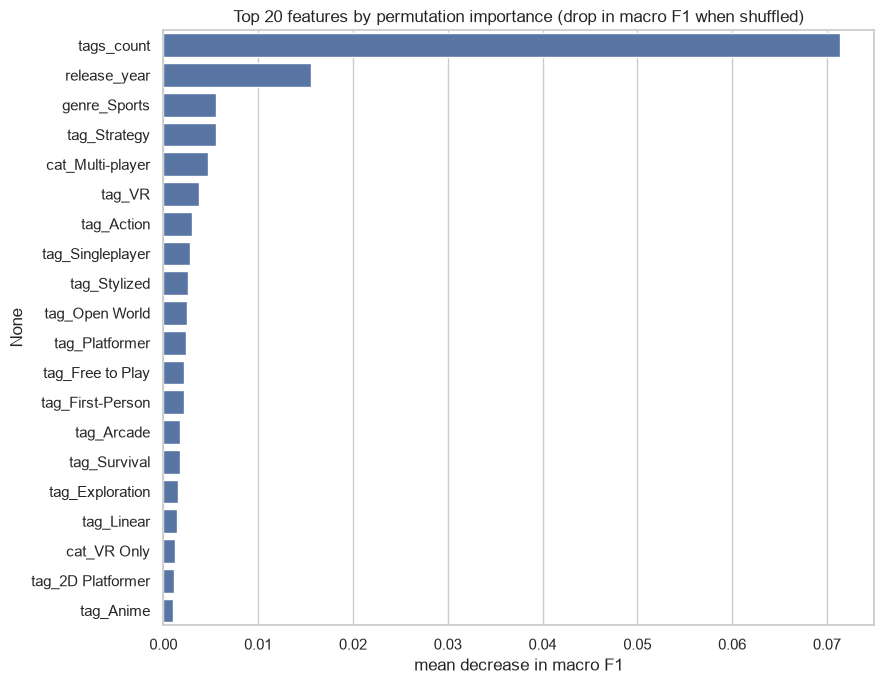

In [95]:
from sklearn.inspection import permutation_importance

# Subsampled for runtime: 118 features x 3 shuffles is a lot of scoring passes.
sample = Xy_test.sample(8000, random_state=42)

perm = permutation_importance(
    with_year, sample, yy_test.loc[sample.index],
    scoring="f1_macro", n_repeats=3, random_state=42, n_jobs=-1,
)

importance = (
    pd.Series(perm.importances_mean, index=Xy_test.columns)
    .sort_values(ascending=False)
)

top = importance.head(20)

plt.figure(figsize=(9, 7))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 20 features by permutation importance (drop in macro F1 when shuffled)")
plt.xlabel("mean decrease in macro F1")
plt.tight_layout()

print(f"release_year rank: {list(importance.index).index('release_year') + 1} of {len(importance)}")


## 21. The leak we missed

`tags_count` is the most important feature by a factor of 4.6 over the next one — and it should never have been in the model.

Steam tags are applied by **players**, not developers. They accumulate over a game's life as people play it and engage with its store page. Section 9 showed that `tags_count` is capped at 20 and that 33,494 games pile up exactly at that ceiling; hitting the ceiling means a game attracted enough community attention to be tagged twenty times. So `tags_count` is not a description of the game — it is a proxy for how many players engaged with it. The model located the best available stand-in for popularity and leaned on it.

Applying that test properly disqualifies two more features that had passed a looser reading of "is this about the game rather than its reviews?":

| Feature | Why it looked safe | Why it is actually post-launch |
| --- | --- | --- |
| `tags_count` | a property of the store page | community-applied, accumulates with engagement, capped at 20 |
| `dlc_count` | a catalog fact | DLC ships *after* the base game, and mostly for games successful enough to justify more |
| `supported_languages_count`, `full_audio_languages_count` | a shipping decision | localisation is frequently added post-launch, and mostly for games that sold well |

All three accumulate over a game's lifetime, and accumulate *faster for successful games*. That is the same leakage as `positive` or `peak_ccu`, only better disguised — which is precisely why it survived the first audit in section 14.

Tag *identity* features (`tag_Action`, `tag_VR`) are treated differently and kept: which tags a game attracts describes what the game is, and genre-level content is knowable before release even though the specific labels are community-applied. The caveat is noted rather than pretended away.

The honest test is to retrain without the three leaky features and see how much of the previous score was borrowed.


In [96]:
LEAKY = ["tags_count", "dlc_count", "supported_languages_count", "full_audio_languages_count"]

X_clean = X_rich.drop(columns=LEAKY)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean, y, test_size=0.2, stratify=y, random_state=42
)

clean = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
clean.fit(Xc_train, yc_train)
clean_pred = clean.predict(Xc_test)

clean_off_by = (yc_test.map(rank).to_numpy() - pd.Series(clean_pred).map(rank).to_numpy())

print(f"{'':<22}{'with leaks':>13}{'leak-free':>12}")
print(f"{'features':<22}{X_rich.shape[1]:>13}{X_clean.shape[1]:>12}")
print(f"{'accuracy':<22}{accuracy_score(yr_test, rich_pred):>13.3f}{accuracy_score(yc_test, clean_pred):>12.3f}")
print(f"{'macro F1':<22}{f1_score(yr_test, rich_pred, average='macro'):>13.3f}"
      f"{f1_score(yc_test, clean_pred, average='macro'):>12.3f}")
print(f"{'within one bucket':<22}{(abs(rich_off_by) <= 1).mean():>13.3f}{(abs(clean_off_by) <= 1).mean():>12.3f}")
print()
print(classification_report(yc_test, clean_pred, labels=class_order, zero_division=0))


                         with leaks   leak-free
features                        117         113
accuracy                      0.613       0.598
macro F1                      0.248       0.230
within one bucket             0.855       0.843

                   precision    recall  f1-score   support

        0 - 20000       0.95      0.68      0.79     18554
    20000 - 50000       0.19      0.44      0.26      2282
   50000 - 100000       0.12      0.21      0.16      1074
  100000 - 200000       0.11      0.18      0.14       694
  200000 - 500000       0.14      0.21      0.17       573
 500000 - 1000000       0.08      0.21      0.12       231
1000000 - 2000000       0.09      0.25      0.13       146
2000000 - 5000000       0.08      0.19      0.11        81
         5000000+       0.14      0.30      0.19        44

         accuracy                           0.60     23679
        macro avg       0.21      0.30      0.23     23679
     weighted avg       0.78      0.60      0.66 

In [97]:
tag_indicator_sum = X_rich[[c for c in X_rich.columns if c.startswith("tag_")]].sum(axis=1)

print("correlation between summed tag indicators and tags_count: "
      f"{tag_indicator_sum.corr(model_df['tags_count']):.3f}")


correlation between summed tag indicators and tags_count: 0.936


Removing the single most important feature cost almost nothing — accuracy 0.613 → 0.598, macro F1 0.248 → 0.230. That looks contradictory until the two questions are separated:

- **Permutation importance** asks *how much does this trained model rely on this feature?* Shuffling `tags_count` broke something the model had built itself around, so its score collapsed.
- **Retraining without it** asks *how much unique information does this feature carry that nothing else does?* Given the chance to learn afresh, the model routed around the gap.

It could route around it because the information is still there. The summed tag indicators correlate with `tags_count` at **0.936** — a game with many of the top-60 tags flagged implicitly has a high tag count. So dropping the column mitigated the leak without removing it.

Fully removing it means dropping every tag feature, which also discards legitimate content signal. Worth measuring rather than assuming, so the next cell trains a third model with no tag-derived features at all — the honest floor.


In [98]:
X_notags = X_clean.drop(columns=[c for c in X_clean.columns if c.startswith("tag_")])

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_notags, y, test_size=0.2, stratify=y, random_state=42
)

notags = HistGradientBoostingClassifier(class_weight="balanced", random_state=42)
notags.fit(Xn_train, yn_train)
notags_pred = notags.predict(Xn_test)

notags_off_by = (yn_test.map(rank).to_numpy() - pd.Series(notags_pred).map(rank).to_numpy())

rows = [
    ("all features",      X_rich.shape[1],   yr_test, rich_pred,   rich_off_by),
    ("no leaky counts",   X_clean.shape[1],  yc_test, clean_pred,  clean_off_by),
    ("no tags at all",    X_notags.shape[1], yn_test, notags_pred, notags_off_by),
]

print(f"{'':<18}{'features':>10}{'accuracy':>10}{'macro F1':>10}{'within 1':>10}")
for name, n_feat, y_true, y_pred, offs in rows:
    print(f"{name:<18}{n_feat:>10}{accuracy_score(y_true, y_pred):>10.3f}"
          f"{f1_score(y_true, y_pred, average='macro'):>10.3f}{(abs(offs) <= 1).mean():>10.3f}")


                    features  accuracy  macro F1  within 1
all features             117     0.613     0.248     0.855
no leaky counts          113     0.598     0.230     0.843
no tags at all            53     0.565     0.193     0.796


| Model | Features | Accuracy | Macro F1 | Within 1 bucket |
| --- | --- | --- | --- | --- |
| all features | 117 | 0.613 | 0.248 | 0.855 |
| no leaky counts | 113 | 0.598 | 0.230 | 0.843 |
| no tag features at all | 53 | 0.565 | 0.193 | 0.796 |

The fully clean model scores macro F1 0.193 — the same figure the original eleven-feature model reached. The genre, category and publisher features recover roughly as much genuine signal as the leaky counts were supplying illegitimately. Put differently, about **22% of the best model's macro F1 came from information a developer would not have on launch day**.

### Which model to ship, and why it is not simply the best-scoring one

There is a second problem with the tag features that only appears at prediction time. The model learned the relationship "many tag indicators set → popular game" from a catalog of *mature* games, whose tag sets were filled in by years of community activity. A developer using this to evaluate an unreleased game would enter the four or five tags they plan to launch with. The model would read that sparse tag set as evidence of an unpopular game and predict accordingly — an artifact of the training distribution, not a prediction about the game.

This is distinct from the training-time leakage above. Even with `tags_count` removed, the tag indicators carry a train/serve mismatch: the same input means different things for a mature catalog entry and a pre-release title.

The 53-feature model is immune to it, at the cost of ~0.04 macro F1. Rather than pick one, the dashboard ships **both** and shows their predictions side by side, with this explanation attached — making the trade-off part of what the project demonstrates rather than a decision hidden behind a single number.

### What the model actually establishes

- Pre-launch catalog metadata carries **real but limited** signal about a game's eventual reach.
- It is much better at **ranking** than at exact classification: 79.6% of leak-free predictions land within one bucket, and mega-hits are essentially never confused with flops.
- The features that matter are what a game *is* — its genre, its tags, its publisher's scale — not how many attributes it lists.
- Most of the variance lives in things this dataset cannot see: marketing spend, review scores, streamer coverage, timing, and quality. A model of this shape should not be expected to find them, and one claiming to would be worth distrusting.


## 22. Saving the models

Both models are saved together with the column lists, class ordering and vocabularies the dashboard needs to build a valid input row — plus their test metrics, so the app can display real numbers rather than hard-coded ones that would drift out of date if the notebook were rerun.


In [99]:
import joblib

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Everything the dashboard needs to rebuild an input row and label a prediction.
bundle = {
    "model_with_tags": clean,          # 113 features, higher score, train/serve mismatch on tags
    "model_no_tags": notags,           # 53 features, immune to that mismatch
    "columns_with_tags": list(X_clean.columns),
    "columns_no_tags": list(X_notags.columns),
    "class_order": class_order,
    "genre_vocab": [c[len("genre_"):] for c in X_clean.columns if c.startswith("genre_")],
    "tag_vocab": [c[len("tag_"):] for c in X_clean.columns if c.startswith("tag_")],
    "category_vocab": [c[len("cat_"):] for c in X_clean.columns if c.startswith("cat_")],
    "metrics": {
        "with_tags": {
            "accuracy": accuracy_score(yc_test, clean_pred),
            "macro_f1": f1_score(yc_test, clean_pred, average="macro"),
            "within_one": float((abs(clean_off_by) <= 1).mean()),
        },
        "no_tags": {
            "accuracy": accuracy_score(yn_test, notags_pred),
            "macro_f1": f1_score(yn_test, notags_pred, average="macro"),
            "within_one": float((abs(notags_off_by) <= 1).mean()),
        },
    },
}

path = os.path.join(MODEL_DIR, "owners_classifier.joblib")
joblib.dump(bundle, path)
print(f"saved {os.path.getsize(path) / 1024:.0f} KB -> {path}")


saved 2353 KB -> ../models\owners_classifier.joblib


## 23. Export

Parquet stores the parsed list columns natively, so reloading needs no re-parsing, and it compresses the heavily repeated genre and tag strings well — 927MB of raw CSV lands at roughly 32MB, small enough to commit and to load straight into the dashboard app.

In [87]:
os.makedirs(os.path.dirname(PROCESSED_PARQUET), exist_ok=True)
df.to_parquet(PROCESSED_PARQUET, index=False)

print(f"{os.path.getsize(PROCESSED_PARQUET) / (1024 * 1024):.1f} MB")

31.7 MB
